<a href="https://colab.research.google.com/github/amber1714/ML-Case-Studies/blob/main/02_Regression/Linear_Ridge_Lasso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linear, Ridge and Lasso Regression — California Housing

**Objective:** Compare Linear Regression with L2-regularized Ridge and L1-regularized Lasso using common regression metrics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01)
}

rows = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(rows)
results_df


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
1,Ridge Regression,0.533193,0.555855,0.745557,0.575816
2,Lasso Regression,0.535326,0.548255,0.740442,0.581615


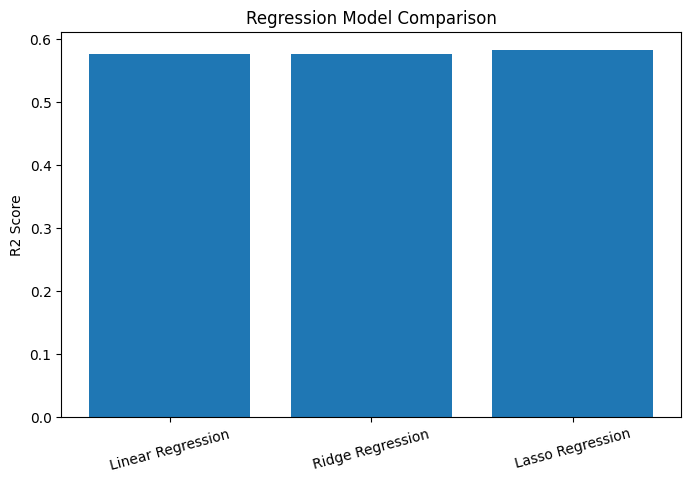

In [5]:
plt.figure(figsize=(8, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.ylabel("R2 Score")
plt.title("Regression Model Comparison")
plt.xticks(rotation=15)
plt.show()


## Regularization

- **Linear Regression:** no regularization.
- **Ridge:** adds an L2 penalty and shrinks coefficients.
- **Lasso:** adds an L1 penalty and can drive some coefficients to zero.


In [6]:
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_rows = []
lasso_rows = []

for alpha in alpha_values:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_pred = ridge.predict(X_test_scaled)
    ridge_rows.append([alpha, r2_score(y_test, ridge_pred)])

    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_pred = lasso.predict(X_test_scaled)
    lasso_rows.append([alpha, r2_score(y_test, lasso_pred)])

print("Ridge alpha comparison")
display(pd.DataFrame(ridge_rows, columns=["Alpha", "R2"]))

print("Lasso alpha comparison")
display(pd.DataFrame(lasso_rows, columns=["Alpha", "R2"]))


Ridge alpha comparison


,Alpha,R2
0,0.001,0.575788
1,0.010,0.575788
2,0.100,0.575791
3,1.000,0.575816
4,10.000,0.576060
5,100.000,0.577791


Lasso alpha comparison


,Alpha,R2
0,0.001,0.576856
1,0.010,0.581615
2,0.100,0.481361
3,1.000,-0.000219
4,10.000,-0.000219
5,100.000,-0.000219


In [7]:
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)
lasso = Lasso(alpha=0.01, max_iter=10000).fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Ridge_Coefficient": ridge.coef_,
    "Lasso_Coefficient": lasso.coef_
})
coef_df


,Feature,Ridge_Coefficient,Lasso_Coefficient
0,MedInc,0.854327,0.800957
1,HouseAge,0.122624,0.127087
2,AveRooms,-0.294210,-0.162759
3,AveBedrms,0.339008,0.206207
4,Population,-0.002282,-0.000000
5,AveOccup,-0.040833,-0.030602
6,Latitude,-0.896168,-0.790113
7,Longitude,-0.869071,-0.755674


## Inference

Compare the models using MAE/RMSE and R². Explain how regularization changes the coefficients and why alpha controls penalty strength.
